In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

print("Project loaded successfully.")
print("Train path:", train_path)
print("Test path:", test_path)

Mounted at /content/drive
Project loaded successfully.
Train path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/data/raw/archive/data/data/train
Test path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/data/raw/archive/data/data/test


In [3]:
# Load A-8 training and test data

train_A8 = np.load(train_path + '/A-8.npy')
test_A8 = np.load(test_path + '/A-8.npy')

# We use the first column as the telemetry signal
train_telemetry_A8 = train_A8[:, 0]
test_telemetry_A8 = test_A8[:, 0]

print("Training telemetry shape:", train_telemetry_A8.shape)
print("Test telemetry shape:", test_telemetry_A8.shape)

Training telemetry shape: (762,)
Test telemetry shape: (8375,)


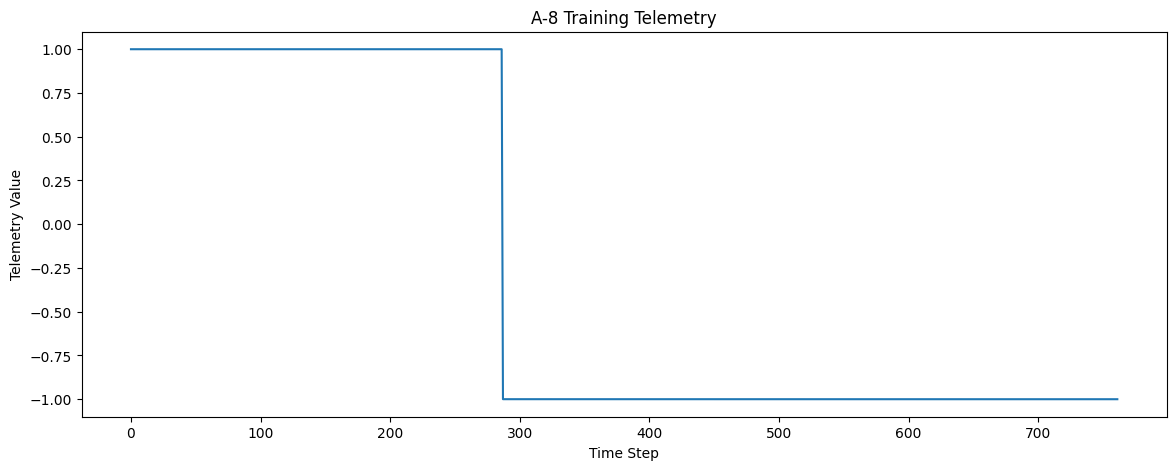

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(train_telemetry_A8)

plt.title("A-8 Training Telemetry")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")

plt.show()

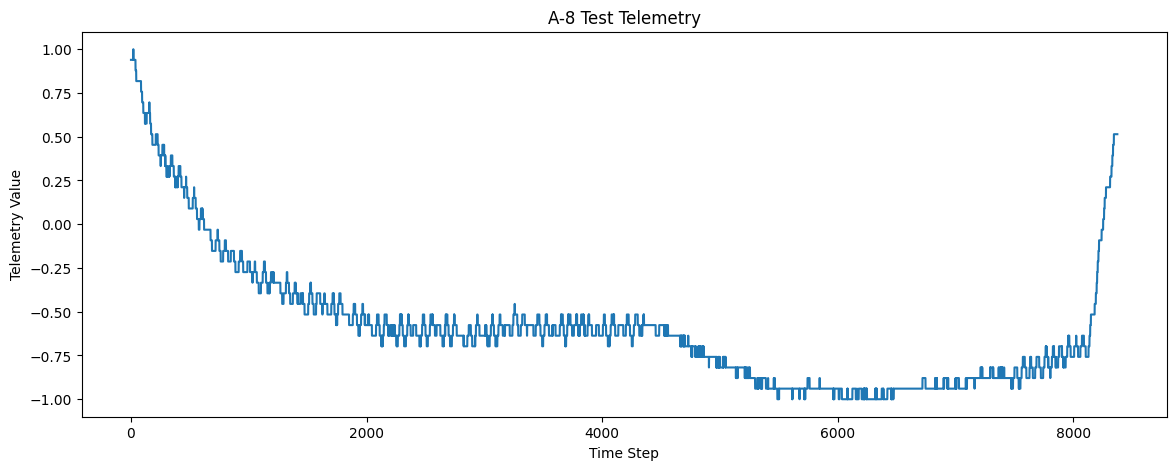

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(test_telemetry_A8)

plt.title("A-8 Test Telemetry")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")

plt.show()

In [6]:
# Load A-8 test telemetry
test_A8 = np.load(test_path + '/A-8.npy')
test_telemetry_A8 = test_A8[:, 0]

# Create ground-truth anomaly labels
anomaly_labels_A8 = np.zeros(len(test_telemetry_A8), dtype=int)
anomaly_labels_A8[4569:8375] = 1

print("Telemetry points:", len(test_telemetry_A8))
print("Normal points:", np.sum(anomaly_labels_A8 == 0))
print("Anomaly points:", np.sum(anomaly_labels_A8 == 1))

Telemetry points: 8375
Normal points: 4569
Anomaly points: 3806


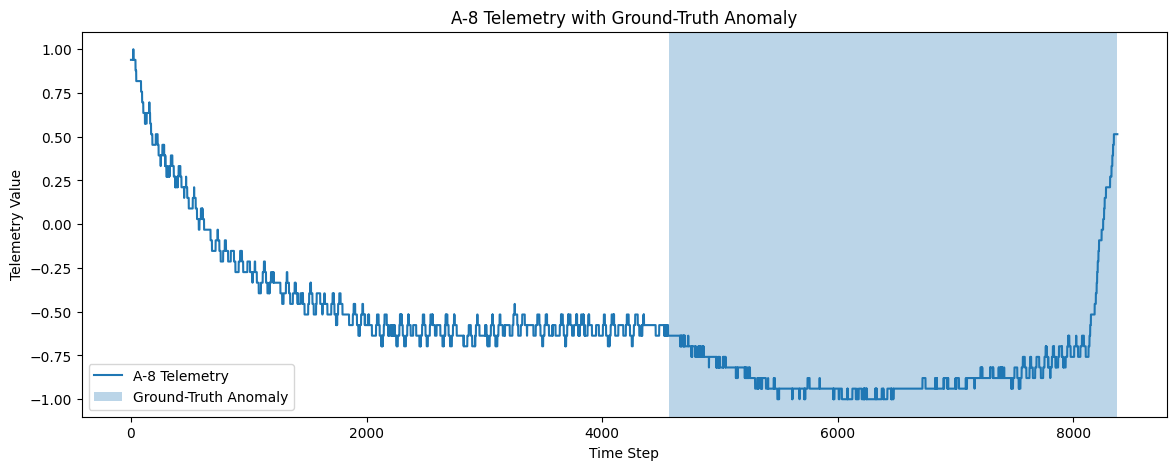

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(test_telemetry_A8, label="A-8 Telemetry")

plt.axvspan(
    4569,
    8374,
    alpha=0.3,
    label="Ground-Truth Anomaly"
)

plt.title("A-8 Telemetry with Ground-Truth Anomaly")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

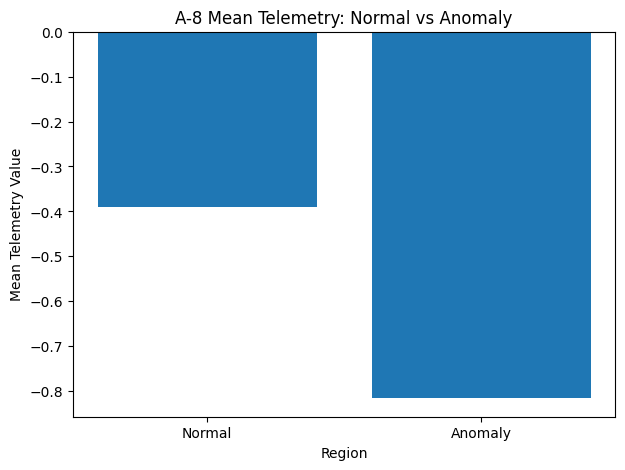

Normal mean: -0.3906871582666503
Anomaly mean: -0.8162289176600386


In [8]:
normal_A8 = test_telemetry_A8[:4569]
anomaly_A8 = test_telemetry_A8[4569:8375]

normal_mean = normal_A8.mean()
anomaly_mean = anomaly_A8.mean()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal", "Anomaly"],
    [normal_mean, anomaly_mean]
)

plt.title("A-8 Mean Telemetry: Normal vs Anomaly")
plt.xlabel("Region")
plt.ylabel("Mean Telemetry Value")

plt.show()

print("Normal mean:", normal_mean)
print("Anomaly mean:", anomaly_mean)

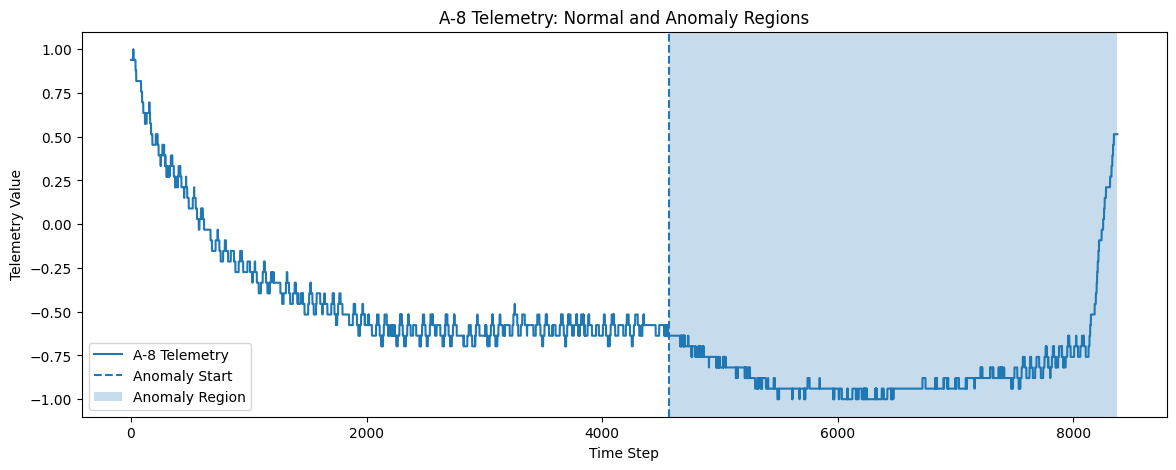

In [9]:
plt.figure(figsize=(14, 5))

# Plot telemetry
plt.plot(test_telemetry_A8, label="A-8 Telemetry")

# Mark the boundary between normal and anomaly
plt.axvline(
    x=4569,
    linestyle="--",
    label="Anomaly Start"
)

# Shade the anomaly region
plt.axvspan(
    4569,
    8374,
    alpha=0.25,
    label="Anomaly Region"
)

plt.title("A-8 Telemetry: Normal and Anomaly Regions")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

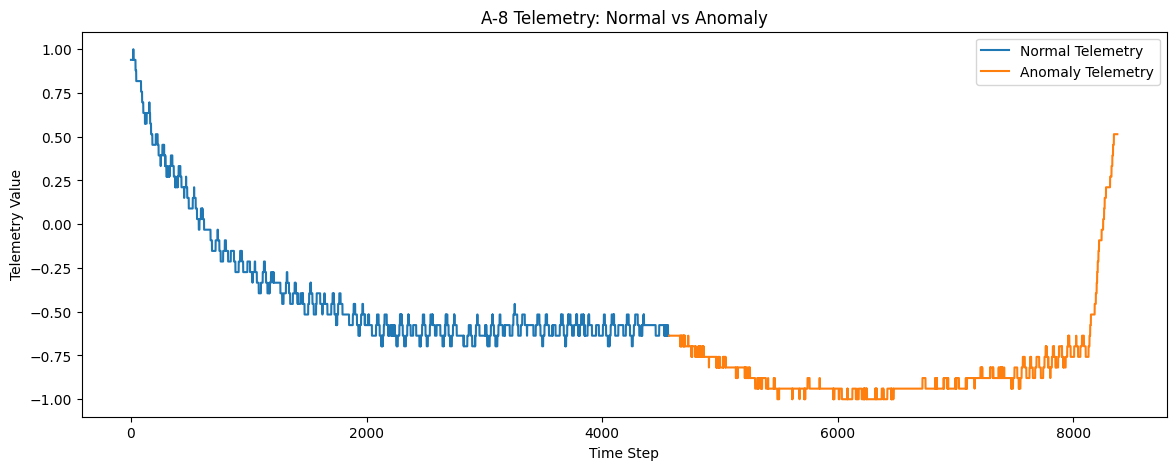

In [10]:
normal_signal = test_telemetry_A8.copy()
anomaly_signal = test_telemetry_A8.copy()

# Hide the opposite region
normal_signal[4569:] = np.nan
anomaly_signal[:4569] = np.nan

plt.figure(figsize=(14, 5))

plt.plot(normal_signal, label="Normal Telemetry")
plt.plot(anomaly_signal, label="Anomaly Telemetry")

plt.title("A-8 Telemetry: Normal vs Anomaly")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

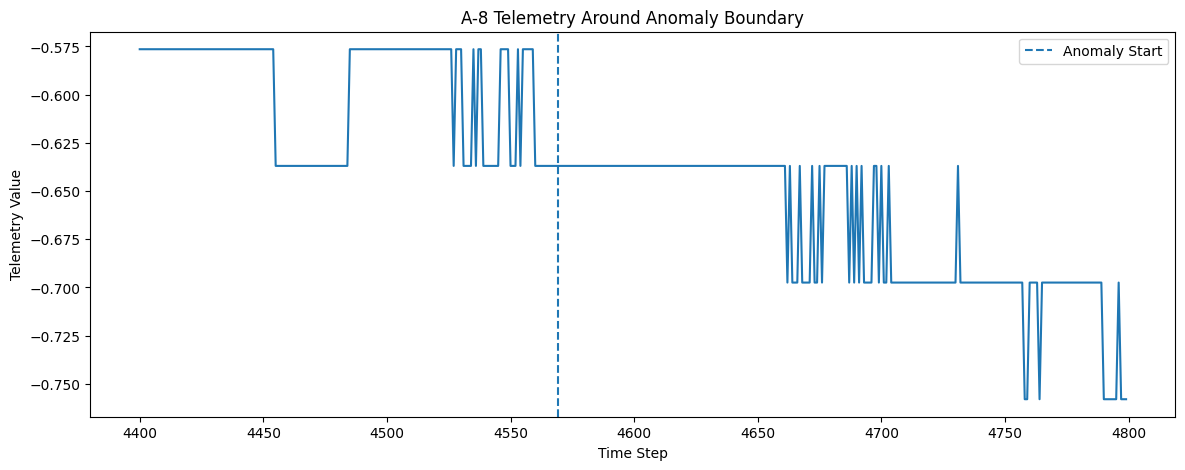

In [11]:
start = 4400
end = 4800

plt.figure(figsize=(14, 5))

plt.plot(
    range(start, end),
    test_telemetry_A8[start:end]
)

plt.axvline(
    x=4569,
    linestyle="--",
    label="Anomaly Start"
)

plt.title("A-8 Telemetry Around Anomaly Boundary")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

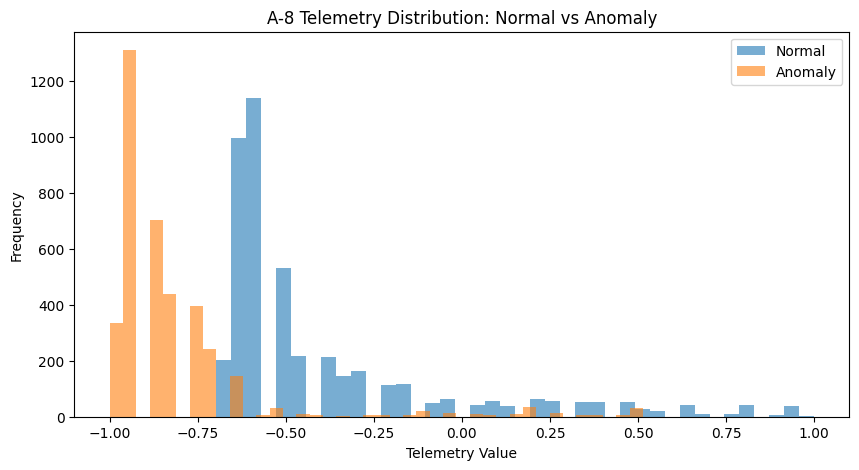

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    normal_A8,
    bins=40,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    anomaly_A8,
    bins=40,
    alpha=0.6,
    label="Anomaly"
)

plt.title("A-8 Telemetry Distribution: Normal vs Anomaly")
plt.xlabel("Telemetry Value")
plt.ylabel("Frequency")
plt.legend()

plt.show()

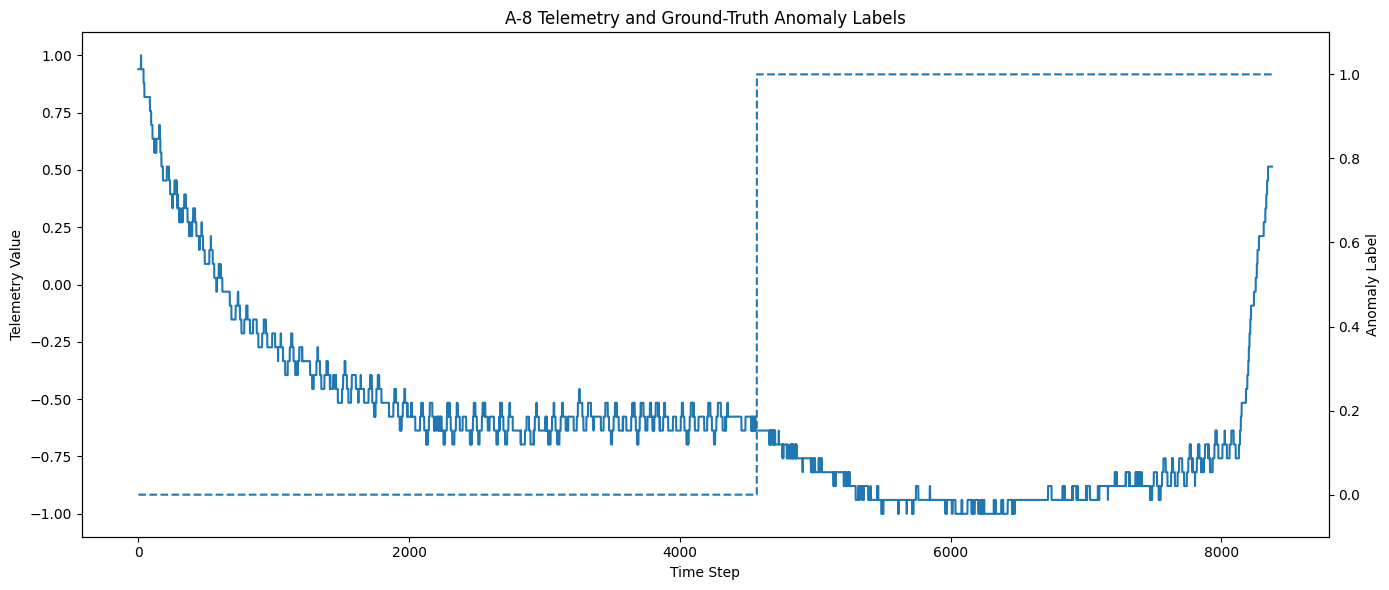

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Telemetry
ax1.plot(
    test_telemetry_A8,
    label="A-8 Telemetry"
)

ax1.set_xlabel("Time Step")
ax1.set_ylabel("Telemetry Value")

# Ground-truth anomaly
ax2 = ax1.twinx()

ax2.plot(
    anomaly_labels_A8,
    linestyle="--",
    label="Ground-Truth Label"
)

ax2.set_ylabel("Anomaly Label")
ax2.set_ylim(-0.1, 1.1)

plt.title("A-8 Telemetry and Ground-Truth Anomaly Labels")

fig.tight_layout()
plt.show()

#github push

In [22]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git add notebooks/04_data_visualization.ipynb
!git commit -m "Add data visualization notebook"
!git push origin main

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@e451ce104bc3.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [23]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

print("Git identity configured.")

Git identity configured.


In [24]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git add notebooks/04_data_visualization.ipynb
!git commit -m "Add data visualization notebook"
!git push origin main

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
[main 0f88d8f] Add data visualization notebook
 1 file changed, 1 insertion(+)
 create mode 100644 notebooks/04_data_visualization.ipynb
fatal: could not read Username for 'https://github.com': No such device or address


In [27]:
!git config --global credential.helper cache

import getpass
import subprocess

token = getpass.getpass("Enter your GitHub Personal Access Token: ")

credential = f"protocol=https\nhost=github.com\nusername=Amit-Chandra-Das\npassword={token}\n\n"

subprocess.run(
    ["git", "credential", "approve"],
    input=credential,
    text=True
)

del token

print("GitHub authentication saved.")

Enter your GitHub Personal Access Token: ··········
GitHub authentication saved.


In [28]:
!git push origin main

Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 376.35 KiB | 8.75 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   09a17c7..0f88d8f  main -> main
